In [29]:
#1.import
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
from tqdm import tqdm

In [30]:
#2.Swin Encoder
class SwinEncoder(nn.Module):
    def __init__(self, model_name="swin_tiny_patch4_window7_224"):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=False,        # 关闭下载
            features_only=True,
            img_size=256,            # 和数据对齐
            dynamic_img_size=True
        )

        self.out_channels = self.backbone.feature_info.channels()

    def forward(self, x):
        feats = self.backbone(x)

        # 🔥 如果是 NHWC，转成 NCHW
        feats = [
            f.permute(0, 3, 1, 2).contiguous()
            if f.ndim == 4 and f.shape[1] != self.out_channels[i]
            else f
            for i, f in enumerate(feats)
        ]

        return feats

In [31]:
#3.Channel Adapter
class ChannelAdapter(nn.Module):
    def __init__(self, in_channels, out_ch):
        super().__init__()
        self.adapters = nn.ModuleList([
            nn.Conv2d(in_ch, out_ch, 1)
            for in_ch in in_channels
        ])

    def forward(self, feats):
        return [conv(f) for conv, f in zip(self.adapters, feats)]

In [32]:
#4.ASPP
class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch, rates=(1, 2, 4)):
        super().__init__()

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            ),
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=rates[0], dilation=rates[0], bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            ),
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=rates[1], dilation=rates[1], bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            ),
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=rates[2], dilation=rates[2], bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            ),
        ])

        self.project = nn.Sequential(
            nn.Conv2d(out_ch * 4, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        xs = [b(x) for b in self.branches]
        x = torch.cat(xs, dim=1)
        return self.project(x)

In [33]:
#5.Top-Down FPN
class FPNTopDown(nn.Module):
    def __init__(self, ch, fpn_ch=96):
        super().__init__()

        self.lat2 = nn.Conv2d(ch, fpn_ch, 1)
        self.lat3 = nn.Conv2d(ch, fpn_ch, 1)
        self.lat4 = nn.Conv2d(ch, fpn_ch, 1)

        self.s2 = nn.Conv2d(fpn_ch, fpn_ch, 3, padding=1)
        self.s3 = nn.Conv2d(fpn_ch, fpn_ch, 3, padding=1)
        self.s4 = nn.Conv2d(fpn_ch, fpn_ch, 3, padding=1)

    def forward(self, c2, c3, c4):

        p4 = self.lat4(c4)

        p3 = self.lat3(c3) + F.interpolate(
            p4, size=c3.shape[-2:], mode="bilinear", align_corners=False
        )

        p2 = self.lat2(c2) + F.interpolate(
            p3, size=c2.shape[-2:], mode="bilinear", align_corners=False
        )

        return self.s2(p2), self.s3(p3), self.s4(p4)

In [34]:
#6.Seg Head
class SegHead(nn.Module):
    def __init__(self, in_ch, mid_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, 1, 1)
        )

    def forward(self, x):
        return self.net(x)

In [35]:
#7.model
class SwinASPP_TopDownFPN_DS(nn.Module):
    def __init__(self, fpn_ch=96):
        super().__init__()

        self.encoder = SwinEncoder()
        self.adapter = ChannelAdapter(self.encoder.out_channels, fpn_ch)

        self.aspp = ASPP(fpn_ch, fpn_ch)
        self.fpn  = FPNTopDown(fpn_ch, fpn_ch)

        self.head_final = SegHead(fpn_ch)
        self.head_p2 = SegHead(fpn_ch)
        self.head_p3 = SegHead(fpn_ch)
        self.head_p4 = SegHead(fpn_ch)

    def forward(self, x):

        H, W = x.shape[-2:]

        feats = self.encoder(x)
        feats = self.adapter(feats)

        # 打印一次确认（调试完可删除）
        # print([f.shape for f in feats])

        c2, c3, c4 = feats[1], feats[2], feats[3]

        c4 = self.aspp(c4)

        p2, p3, p4 = self.fpn(c2, c3, c4)

        out_final = self.head_final(p2)
        out_p2 = self.head_p2(p2)
        out_p3 = self.head_p3(p3)
        out_p4 = self.head_p4(p4)

        # 上采样回原图
        out_final = F.interpolate(out_final, size=(H, W), mode="bilinear", align_corners=False)
        out_p2 = F.interpolate(out_p2, size=(H, W), mode="bilinear", align_corners=False)
        out_p3 = F.interpolate(out_p3, size=(H, W), mode="bilinear", align_corners=False)
        out_p4 = F.interpolate(out_p4, size=(H, W), mode="bilinear", align_corners=False)

        return out_final, out_p2, out_p3, out_p4

In [36]:
#8.
model = SwinASPP_TopDownFPN_DS(fpn_ch=96).to(device)
print("Model:", model.__class__.__name__)

Model: SwinASPP_TopDownFPN_DS


In [37]:
#9.优化器
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

In [38]:
#10.Train / Validate
@torch.no_grad()
def validate(model, loader):
    model.eval()
    losses, dices, ious = [], [], []

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        loss = total_loss_multiscale(outputs, masks)

        logits_final = outputs[0]
        dice, iou = dice_iou_from_logits(logits_final, masks)

        losses.append(loss.item())
        dices.append(dice)
        ious.append(iou)

    return float(np.mean(losses)), float(np.mean(dices)), float(np.mean(ious))


def train_one_epoch(model, loader):
    model.train()
    losses = []

    for imgs, masks in tqdm(loader, leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        loss = total_loss_multiscale(outputs, masks)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))

In [39]:
#11.train
best_val_dice = -1.0

for epoch in range(1, cfg.epochs+1):

    tr_loss = train_one_epoch(model, train_loader)
    val_loss, val_dice, val_iou = validate(model, val_loader)
    scheduler.step()

    print(f"Epoch {epoch:02d} | "
          f"train {tr_loss:.4f} | "
          f"val {val_loss:.4f} | "
          f"dice {val_dice:.4f} | "
          f"iou {val_iou:.4f}")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_swin_fpn.pt")
        print("  ✅ saved best model")

Epoch 01 | train 1.2055 | val 1.1280 | dice 0.5448 | iou 0.5072
  ✅ saved best model


Epoch 02 | train 0.9560 | val 0.9238 | dice 0.5986 | iou 0.5672
  ✅ saved best model


Epoch 03 | train 0.8161 | val 0.9197 | dice 0.6485 | iou 0.6154
  ✅ saved best model


Epoch 04 | train 0.7241 | val 0.8301 | dice 0.4077 | iou 0.3677


Epoch 05 | train 0.6654 | val 0.8197 | dice 0.6316 | iou 0.6000


...

Epoch 16 | train 0.5369 | val 0.7390 | dice 0.6613 | iou 0.6237


Epoch 17 | train 0.5346 | val 0.7373 | dice 0.6499 | iou 0.6120


Epoch 18 | train 0.5320 | val 0.7374 | dice 0.6647 | iou 0.6272


Epoch 19 | train 0.5310 | val 0.7385 | dice 0.6804 | iou 0.6428
  ✅ saved best model


Epoch 20 | train 0.5308 | val 0.7382 | dice 0.6709 | iou 0.6334


In [40]:
#12. Dice / IoU 计算（从 logits）
import numpy as np

def dice_iou_from_logits(logits, masks, eps=1e-6):
    """
    logits: [B,1,H,W]
    masks : [B,1,H,W]
    """

    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    masks = masks.float()

    intersection = (preds * masks).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3))

    dice = (2 * intersection + eps) / (union + eps)

    iou = (intersection + eps) / (
        preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) - intersection + eps
    )

    return float(dice.mean().cpu()), float(iou.mean().cpu())

In [41]:
#13.多尺度 Loss
def total_loss_multiscale(outputs, masks):
    """
    outputs: (out_final, out_p2, out_p3, out_p4)
    masks:   [B,1,H,W]
    """

    loss_fn = nn.BCEWithLogitsLoss()

    out_final, out_p2, out_p3, out_p4 = outputs

    loss_final = loss_fn(out_final, masks)
    loss_p2    = loss_fn(out_p2, masks)
    loss_p3    = loss_fn(out_p3, masks)
    loss_p4    = loss_fn(out_p4, masks)

    return (
        1.0 * loss_final +
        0.5 * loss_p2 +
        0.5 * loss_p3 +
        0.5 * loss_p4
    )

In [43]:
#14.测试
@torch.no_grad()
def evaluate_test(model, loader):
    model.eval()

    losses, dices, ious = [], [], []

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        loss = total_loss_multiscale(outputs, masks)

        logits = outputs[0]   # 只用最终输出

        dice, iou = dice_iou_from_logits(logits, masks)

        losses.append(loss.item())
        dices.append(dice)
        ious.append(iou)

    return np.mean(losses), np.mean(dices), np.mean(ious)

In [44]:
@torch.no_grad()
def predict_prob_pred(model, img, thr=0.5):
    """
    img: [C,H,W]
    """
    model.eval()

    logits = model(img.unsqueeze(0).to(device))[0]
    prob = torch.sigmoid(logits)[0,0].cpu().numpy()
    pred = (prob > thr).astype(np.uint8)

    return prob, pred

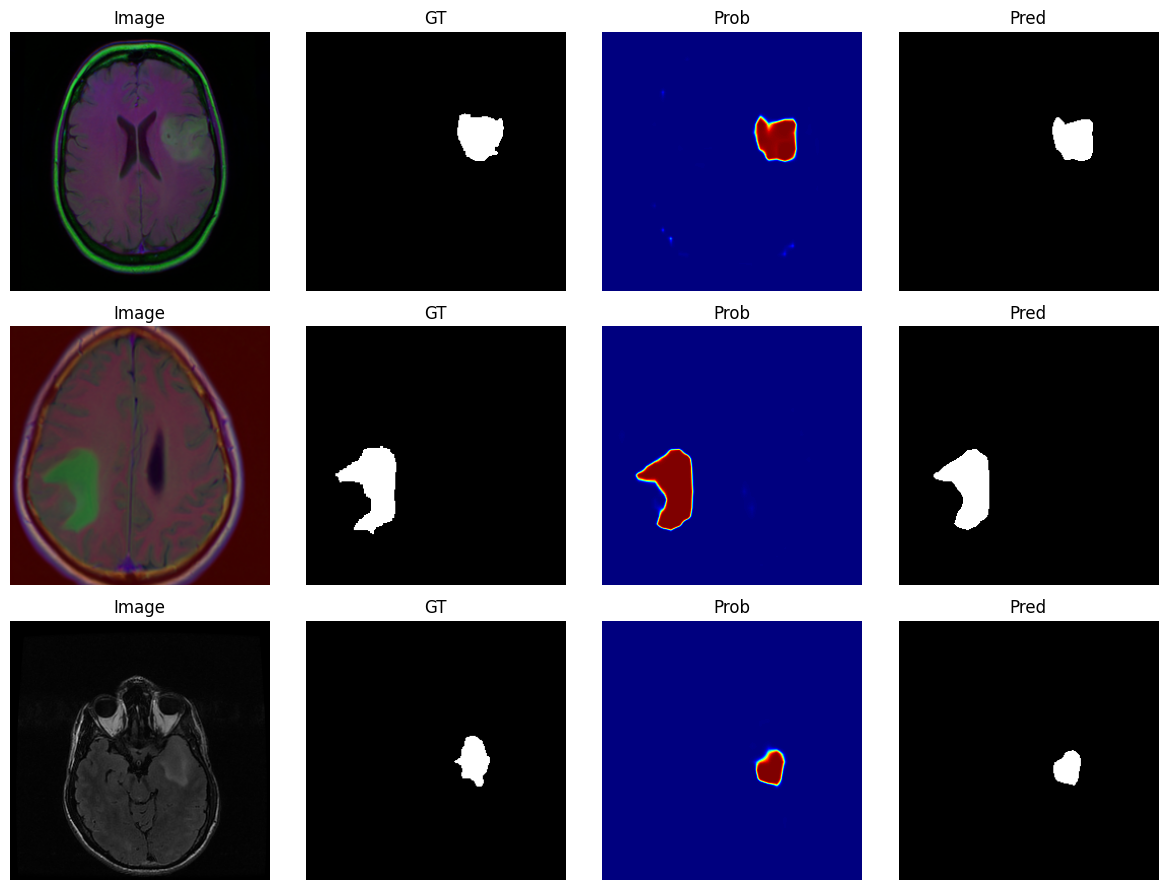

In [59]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

def get_positive_sample(dataset):
    while True:
        img, mask = dataset[np.random.randint(len(dataset))]
        if mask.sum() > 0:
            return img, mask

plt.figure(figsize=(12,9))

for i in range(3):

    img, mask = get_positive_sample(test_ds)

    prob, pred = predict_prob_pred(model, img)

    img_np = img.permute(1,2,0).numpy()
    gt = mask[0].numpy()

    plt.subplot(3,4,i*4+1)
    plt.imshow(img_np)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(3,4,i*4+2)
    plt.imshow(gt, cmap="gray")
    plt.title("GT")
    plt.axis("off")

    plt.subplot(3,4,i*4+3)
    plt.imshow(prob, cmap="jet")
    plt.title("Prob")
    plt.axis("off")

    plt.subplot(3,4,i*4+4)
    plt.imshow(pred, cmap="gray")
    plt.title("Pred")
    plt.axis("off")

plt.tight_layout()
plt.show()

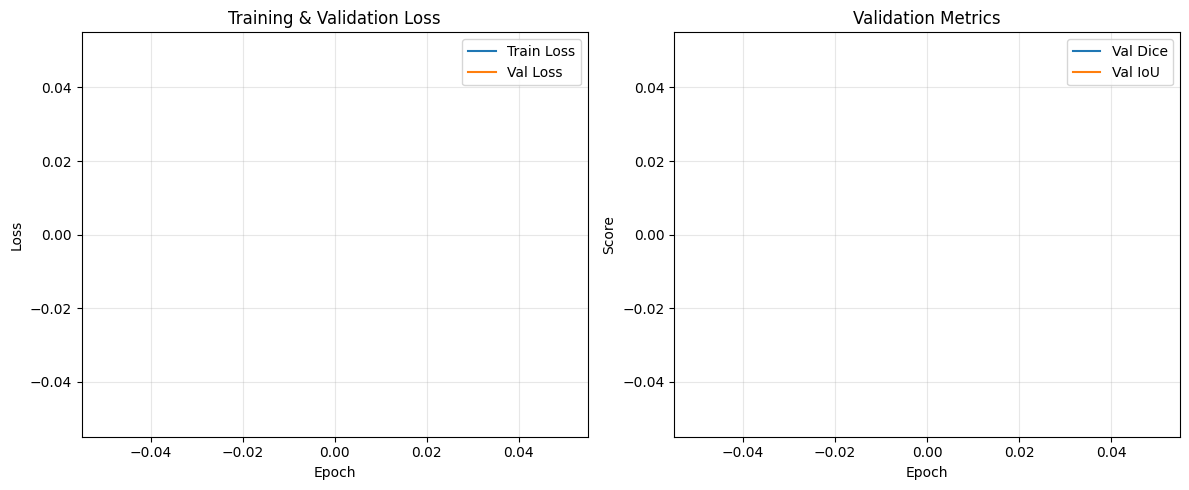

In [61]:
import matplotlib.pyplot as plt

epochs     = [h[0] for h in history]
train_loss = [h[1] for h in history]
val_loss   = [h[2] for h in history]
val_dice   = [h[3] for h in history]
val_iou    = [h[4] for h in history]

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

# Dice / IoU
plt.subplot(1,2,2)
plt.plot(epochs, val_dice, label="Val Dice")
plt.plot(epochs, val_iou, label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()